# Open research questions

This notebook reviews unresolved issues in hybrid modeling: recovering
equations from learned closures, separating process error from numerical error,
extrapolation, state selection, uncertainty, and the appropriate amount of
physical structure. A synthetic example shows why symbolic recovery can be
fragile.

:::{admonition} Time check: 13 minutes
:class: tip
You will test a recovered equation, compare closures across solver resolutions,
and identify concrete checks for a new hybrid-model study.
:::

## Outline

1. Symbolic recovery
2. Solver error and extrapolation
3. State representation and uncertainty
4. Choosing physical constraints
5. Suggested next experiments


In [1]:
# --- Colab bootstrap: installs the workshop package on first run -----------
try:
    import workshop_utils
except ImportError:
    %pip install -q "git+https://github.com/BennettHydroLab/differentiable_modeling_workshop.git"
    import workshop_utils

In [2]:
import time

import numpy as np
import torch
import matplotlib.pyplot as plt

from workshop_utils import MLP, set_style, COLORS
from workshop_utils.data import load_basin, BASIN_TEMPERATE

set_style()
torch.manual_seed(0)

## 1. From learned closure to equation

Sparse regression can fit a compact equation to values sampled from a learned
closure. Rackauckas et al. recover missing Lotka-Volterra terms this way, but
their robustness study reports a $(50.4\pm25.7)\%$ recovery rate over 498
error-free runs {cite}`rackauckas2021universal`.

### Synthetic setup

A bucket model with true relation $q(S)=0.0895S^{1.5}$ generates noisy
pseudo-observations. A neural closure replaces that relation while mass balance
remains fixed. Since the generating equation is known, the symbolic fit can be
graded directly.


In [3]:
ds = load_basin(BASIN_TEMPERATE)
year = ds.sel(time=slice("1998-10-01", "1999-09-30"))
x_eff = torch.tensor(year.prcp.values, dtype=torch.float32) * 0.35   # effective recharge

K_TRUE, C_TRUE = 0.0895, 1.5
q_physics = lambda S: K_TRUE * S.clamp(min=1e-6) ** C_TRUE


def roll(x, q_fn, n_sub=1, S0=15.0, keep_state=False):
    """Integrate dS/dt = x - q(S) with n_sub explicit substeps per day."""
    S, dt, out, states = torch.tensor(S0), 1.0 / n_sub, [], []
    for t in range(len(x)):
        q_day = 0.0
        for _ in range(n_sub):
            states.append(S)
            q = q_fn(S)
            S = torch.nn.functional.softplus(S + dt * (x[t] - q), beta=5.)
            q_day = q_day + dt * q
        out.append(q_day)
    return (torch.stack(out), torch.stack(states)) if keep_state else torch.stack(out)


with torch.no_grad():
    q_obs, S_visited = roll(x_eff, q_physics, n_sub=8, keep_state=True)

torch.manual_seed(1)
q_noisy = q_obs * (1 + 0.05 * torch.randn(len(q_obs)))   # 5% multiplicative noise

print(f"{len(x_eff)} days; storage visited {S_visited.min():.1f} to {S_visited.max():.1f} mm")
print(f"mean flow {q_obs.mean():.2f} mm/day, peak {q_obs.max():.2f} mm/day")

365 days; storage visited 0.8 to 19.9 mm
mean flow 0.90 mm/day, peak 6.86 mm/day


In [4]:
S_SCALE = 20.0   # a fixed scale, not learned -- see 06_practical_guide, section 4


class Closure(torch.nn.Module):
    """q_hat = NN_phi(S). Softplus output because discharge cannot be negative."""

    def __init__(self):
        super().__init__()
        self.net = MLP(1, 1, hidden=12, depth=2)

    def forward(self, S):
        return torch.nn.functional.softplus(self.net((S / S_SCALE).reshape(1, 1))).reshape(())

    def on_grid(self, S_grid):
        return torch.nn.functional.softplus(self.net((S_grid / S_SCALE).reshape(-1, 1))).reshape(-1)


def train_closure(n_sub, n_steps=50, lr=0.03):
    torch.manual_seed(0)
    model = Closure()
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    losses, t0 = [], time.time()
    for step in range(n_steps):
        opt.zero_grad()
        loss = ((roll(x_eff, model, n_sub=n_sub) - q_noisy) ** 2).mean()
        loss.backward()
        opt.step()
        losses.append(loss.item())
        if step % 10 == 0:
            print(f"  step {step:3d}   MSE {loss.item():.4f}")
    return model, losses, time.time() - t0


model_fine, loss_fine, t_fine = train_closure(n_sub=4)
print(f"\ntrained in {t_fine:.0f} s; MSE {loss_fine[0]:.3f} -> {loss_fine[-1]:.4f}")

  step   0   MSE 0.8940


  step  10   MSE 0.3137


  step  20   MSE 0.0887


  step  30   MSE 0.0263


  step  40   MSE 0.0173



trained in 43 s; MSE 0.894 -> 0.0139


### Sparse equation fit

Sequentially thresholded least squares fits a library of candidate terms,
removes coefficients below a threshold, and refits. The candidate library and
threshold are modeling choices; both are varied below.


In [5]:
def stlsq(Theta, y, thresh, n_iter=10):
    """Sequentially thresholded least squares. Columns normalized so the
    threshold means the same thing for S and for S^3."""
    norms = np.linalg.norm(Theta, axis=0, keepdims=True)
    Theta_n = Theta / norms
    xi = np.linalg.lstsq(Theta_n, y, rcond=None)[0]
    for _ in range(n_iter):
        keep = np.abs(xi) >= thresh * np.abs(xi).max()
        xi = np.zeros(Theta.shape[1])
        if keep.sum() == 0:
            break
        xi[keep] = np.linalg.lstsq(Theta_n[:, keep], y, rcond=None)[0]
    coef = xi / norms[0]
    resid = np.linalg.norm(Theta @ coef - y) / np.linalg.norm(y)
    return coef, resid


def as_equation(coef, names):
    terms = [f"{c:+.4f} {n}" for c, n in zip(coef, names) if c != 0]
    return "q(S) = " + (" ".join(terms) if terms else "0")


# Sample the closure only where the model actually went.
S_lo, S_hi = float(S_visited.quantile(0.02)), float(S_visited.quantile(0.98))
S_grid = torch.linspace(S_lo, S_hi, 200)
with torch.no_grad():
    q_learned = model_fine.on_grid(S_grid).numpy()
S_np = S_grid.numpy()

NAMES = ["1", "S", "S^1.5", "S^2", "S^3"]
LIBRARY = np.stack([S_np ** p for p in [0, 1, 1.5, 2, 3]], axis=1)

print(f"{'threshold':>10}  {'residual':>9}   recovered equation")
print("-" * 78)
for th in [0.05, 0.10, 0.20, 0.30, 0.50]:
    coef, resid = stlsq(LIBRARY, q_learned, th)
    print(f"{th:>10.2f}  {resid:>9.4f}   {as_equation(coef, NAMES)}")
print("-" * 78)
print(f"{'truth':>10}  {0.0:>9.4f}   q(S) = +{K_TRUE:.4f} S^1.5")

 threshold   residual   recovered equation
------------------------------------------------------------------------------
      0.05     0.0031   q(S) = +0.5611 S -0.4764 S^1.5 +0.1604 S^2 -0.0036 S^3
      0.10     0.0031   q(S) = +0.5611 S -0.4764 S^1.5 +0.1604 S^2 -0.0036 S^3
      0.20     0.0031   q(S) = +0.5611 S -0.4764 S^1.5 +0.1604 S^2 -0.0036 S^3
      0.30     0.0269   q(S) = +0.0950 S^1.5
      0.50     0.0269   q(S) = +0.0950 S^1.5
------------------------------------------------------------------------------
     truth     0.0000   q(S) = +0.0895 S^1.5


A threshold of 0.3 or larger selects $0.0950S^{1.5}$, close to the true
$0.0895S^{1.5}$. A lower threshold gives a denser expression with a smaller
residual. Fit error alone therefore favors the wrong representation.


In [6]:
# (a) What if the true term isn't in your library?
_, resid_correct = stlsq(LIBRARY, q_learned, 0.30)          # the right answer, for reference
NAMES2 = ["1", "S", "S^2", "S^3", "sqrt(S)"]
LIB2 = np.stack([S_np ** p for p in [0, 1, 2, 3, 0.5]], axis=1)
coef2, resid2 = stlsq(LIB2, q_learned, 0.30)
print("library WITHOUT the true term, threshold 0.30")
print(f"   {as_equation(coef2, NAMES2)}")
print(f"   relative residual {resid2:.4f}  (the correct answer scored {resid_correct:.4f})\n")

# (b) How stable is the selection? Perturb the sampled closure and re-fit.
#     NOTE: this is a cheap proxy. It perturbs the closure we already trained;
#     it does NOT retrain from scratch, which is what Rackauckas et al. did.
rng = np.random.default_rng(0)
print(f"{'closure perturbation':>22}{'exactly {S^1.5} selected':>28}")
print("-" * 50)
for level in [0.0, 0.02, 0.05, 0.10, 0.20]:
    hits = sum(
        tuple(np.nonzero(stlsq(LIBRARY, q_learned * (1 + level * rng.standard_normal(len(q_learned))), 0.30)[0])[0]) == (2,)
        for _ in range(100)
    )
    print(f"{level:>21.0%}{hits:>21} / 100")

library WITHOUT the true term, threshold 0.30
   q(S) = +0.1371 S +0.0161 S^2
   relative residual 0.0197  (the correct answer scored 0.0269)

  closure perturbation    exactly {S^1.5} selected
--------------------------------------------------
                   0%                  100 / 100


                   2%                   79 / 100


                   5%                   50 / 100
                  10%                   39 / 100


                  20%                   34 / 100


A candidate library that omits $S^{1.5}$ still returns a compact equation with
a low residual. A 5% perturbation of the learned curve changes term selection
frequently because $S^{1.5}$ is close to combinations of $S$ and $S^2$ over a
limited range. Treat recovered equations as testable hypotheses and report
stability across libraries, thresholds, seeds, and data windows.


## 2. Process error or solver error?

A learned closure minimizes mismatch without knowing whether it came from the
process model, numerical solver, forcing, initial state, or observations. The
same closure is therefore trained with four substeps per day and with one
forward-Euler step per day.


In [7]:
model_coarse, loss_coarse, t_coarse = train_closure(n_sub=1)
print(f"\ntrained in {t_coarse:.0f} s; MSE {loss_coarse[0]:.3f} -> {loss_coarse[-1]:.4f}")

with torch.no_grad():
    q_c = model_coarse.on_grid(S_grid).numpy()

coef_f, res_f = stlsq(LIBRARY, q_learned, 0.30)
coef_c, res_c = stlsq(LIBRARY, q_c, 0.30)
print()
print(f"truth                        {as_equation(np.array([0, 0, K_TRUE, 0, 0]), NAMES)}")
print(f"accurate solver (4 substeps) {as_equation(coef_f, NAMES)}")
print(f"coarse solver   (1 step/day) {as_equation(coef_c, NAMES)}")

  step   0   MSE 0.8936


  step  10   MSE 0.3500


  step  20   MSE 0.2069


  step  30   MSE 0.1440


  step  40   MSE 0.1142



trained in 10 s; MSE 0.894 -> 0.1056

truth                        q(S) = +0.0895 S^1.5
accurate solver (4 substeps) q(S) = +0.0950 S^1.5
coarse solver   (1 step/day) q(S) = +0.2006 S -0.0814 S^1.5 +0.0265 S^2


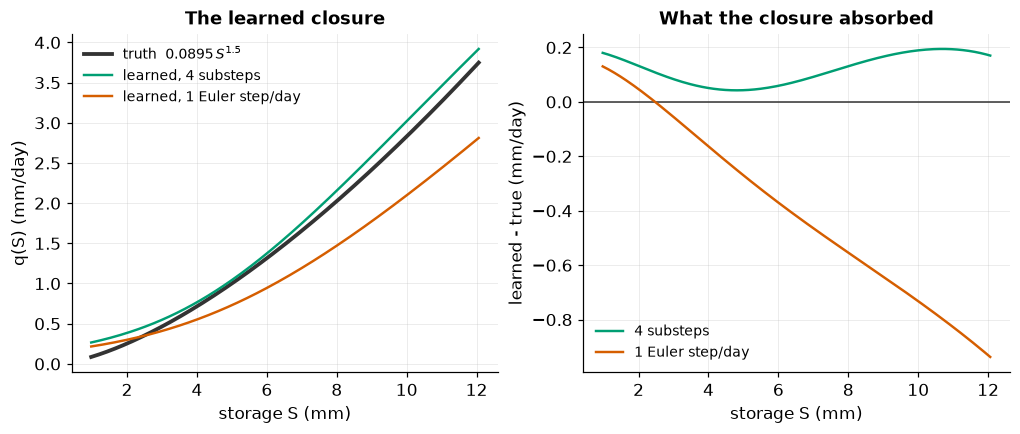

In [8]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4))

a1.plot(S_np, K_TRUE * S_np ** C_TRUE, color=COLORS["obs"], lw=2.5, label=r"truth  $0.0895\,S^{1.5}$")
a1.plot(S_np, q_learned, color=COLORS["hybrid"], label="learned, 4 substeps")
a1.plot(S_np, q_c, color=COLORS["ml"], label="learned, 1 Euler step/day")
a1.set_xlabel("storage S (mm)"); a1.set_ylabel("q(S) (mm/day)")
a1.set_title("The learned closure")
a1.legend(fontsize=9)

err_f = q_learned - K_TRUE * S_np ** C_TRUE
err_c = q_c - K_TRUE * S_np ** C_TRUE
a2.axhline(0, color=COLORS["obs"], lw=1)
a2.plot(S_np, err_f, color=COLORS["hybrid"], label="4 substeps")
a2.plot(S_np, err_c, color=COLORS["ml"], label="1 Euler step/day")
a2.set_xlabel("storage S (mm)"); a2.set_ylabel("learned - true (mm/day)")
a2.set_title("What the closure absorbed")
a2.legend(fontsize=9)
plt.show()

The coarse solver produces a different learned function and a multi-term sparse
fit even though the physical generating relation is unchanged. Compare closure
curves across decreasing step sizes before interpreting them. The same check
should be repeated for known forcing and observation uncertainties.


## 3. State-space coverage

A closure is constrained only over states visited during training. The shaded
range below marks that support.


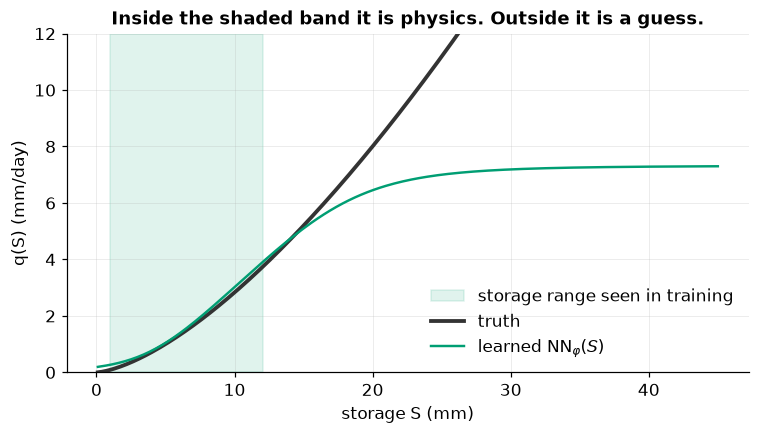

In [9]:
fig, ax = plt.subplots(figsize=(8, 4))
S_wide = torch.linspace(0.1, 45, 300)
with torch.no_grad():
    q_wide = model_fine.on_grid(S_wide).numpy()

ax.fill_betweenx([0, 12], S_lo, S_hi, color=COLORS["hybrid"], alpha=0.12,
                 label="storage range seen in training")
ax.plot(S_wide.numpy(), K_TRUE * S_wide.numpy() ** C_TRUE, color=COLORS["obs"],
        lw=2.5, label="truth")
ax.plot(S_wide.numpy(), q_wide, color=COLORS["hybrid"], label=r"learned $\mathrm{NN}_\varphi(S)$")
ax.set_xlabel("storage S (mm)"); ax.set_ylabel("q(S) (mm/day)")
ax.set_ylim(0, 12)
ax.set_title("Inside the shaded band it is physics. Outside it is a guess.")
ax.legend()
plt.show()

Inside the band the learned closure tracks the truth. Outside it (a wetter
year, a bigger storm, a changed climate) it does whatever a two-layer MLP
does when extrapolating, which is nothing you should rely on. It also drifts at
the dry end, where storage is rarely low enough for the loss to care.

This is a statement of what the method is rather than a flaw in it, but it has
a consequence the literature is only starting to grapple with.

**Hybrids win the dynamics and lose the climatology.** The sharpest published
statement is {cite}`kalauni2025hybrid`'s counter-result. At unseen sites, on
the sub-daily evaporative response, both hybrids beat calibrated physics:
observed latent heat peaks at 107 W/m² near local noon, per-site-calibrated
physics gives 91 W/m² and roughly an hour late, the hybrids give 105 and
107 W/m² in phase. On the long-term evaporative index $E/P$ at those same
sites, the physics wins and the margin is large: Spearman $\rho$ of 0.88 for
physics against 0.68 and 0.66 for the two hybrids.

Partly that is a training-objective artifact: both hybrids were trained on
variance-based losses that do not penalize bias. But the physics models were
calibrated to a variance-based objective too, so it is not purely that. The
limited reading is that a structurally constrained model has its long-term
behavior partly pinned by its structure, and a flexible one does not.

:::{admonition} Open question
:class: note
Do bias-aware or multi-objective losses fix this, or does it need an
architectural constraint (mass closure enforced by construction rather than by
the loss)? Nobody knows. {cite}`shen2023differentiable`'s wish list names
"conservation of mass, energy and momentum" as a target the field has not hit,
and {cite}`lamichhane2025dynamic` note plainly that their hybrid "does not
impose strict mass-balance constraints."

If you want a tractable, publishable problem out of this workshop, this is
probably the best one on offer.
:::

## 4. State representation

Every hybrid model in this workshop started from a model somebody else wrote,
and inherited its state vector along with it. HBV-lite has a soil store and two
routing reservoirs because Bergström chose those in the 1970s. SNOW-17 carries
SWE and heat deficit. {cite}`kalauni2025hybrid` carry
$(w_s, w_r, w_g, T(z,t))$ from the LaD model, and say out loud that "there is
no guarantee that the state vector we inherit from the LaD model is either
sufficient or parsimonious."

That cuts both ways, and both are live questions:

**Insufficient.** If the real system has a memory your state vector cannot
represent (a perched water table, a frozen soil layer, a vegetation state),
then no closure, however flexible, can recover the right dynamics. It will fit
the training data by making $q$ depend on the wrong things.

**Over-parameterized.** Three stores where two would do is three stores among
which the data cannot distinguish. That is section 6 of
`06_practical_guide` arriving from a different direction: some equifinality is
structural rather than parametric.

The alternative is to learn the coordinates too. {cite}`champion2019data`
discover both a latent state and a sparse dynamical equation in it
simultaneously. It works well on toy systems. Nobody has shown it works
on a catchment, and there is a real tension: a learned latent state is not a
soil moisture, so you have traded away the interpretability that was the reason
for the hybrid in the first place.

:::{admonition} Discussion
:class: tip
Take your own model. **Which state variable would you delete first, and how
would you know if you were wrong?** If you cannot name an observation that
would distinguish the model with it from the model without it, that state is
currently a modeling convention rather than a hypothesis.
:::

## 5. Uncertainty and nonstationarity

Three frontiers, briefly, because each deserves more time than this workshop
has.

**Uncertainty quantification.** {cite}`shen2023differentiable`'s abstract
closes on this point: future work should "reduce uncertainty, and verify the
physical significance of outputs." The practical situation today is thin. You
can ensemble over seeds, you can do Monte Carlo dropout, you can put a
distribution on the outputs. None of that is a posterior over the learned
function, and calibrated predictive intervals from hybrid models are not
standard practice. A room full of people who know what GLUE is
{cite}`beven2006manifesto` should find that unsatisfying.

**Nonstationarity and climate projection.** The argument for hybrids here is
attractive: a model whose water balance is enforced by structure ought to
extrapolate to an unseen climate better than one that learned everything from
the historical record. {cite}`shen2023differentiable` make it, and
{cite}`feng2023suitability` provide the most direct evidence. Note the
register: the brief evidence available is preliminary, and section 3 above is a
reason for caution. If a hybrid already loses the long-term water balance at an
unseen site, that is not obviously a model you want to trust in an unseen
climate. The argument is plausible and under-tested. Say that.

**Offline stability is not online stability.** {cite}`brenowitz2020interpreting`
and related work in climate modeling found parameterizations that were
perfectly well behaved offline and destabilized the host model when coupled.
Training online, through the solver, mitigates this, and that is one of the
main arguments for the whole differentiable approach, but it does not eliminate
the problem. If your closure will eventually live inside a long coupled run,
test it there early.

## 6. Degree of physical constraint

This is the question the whole workshop has been circling, and
{cite}`kalauni2025hybrid` give it the cleanest available framing: build the
same model at three points along a spectrum of inductive bias and compare.

| | Physics only | Resistance NN | Full Flux NN |
|---|---|---|---|
| What is learned | nothing | $r_a$, $r_s$; bulk-transfer equations kept | $H$, $LE$ directly |
| H, NSE (per-site) | 0.61 | 0.72 | **0.77** |
| LE, NSE (per-site) | 0.59 | 0.68 | **0.70** |
| H, NSE (unseen sites) | 0.61 | **0.73** | **0.73** |
| LE, NSE (unseen sites) | 0.59 | **0.65** | **0.65** |
| Median absolute bias | reference | **smaller by 2.2-2.5 W/m²** | larger |

Read the rows in order. More neural flexibility wins per site. At unseen sites
the two hybrids become statistically indistinguishable on every variance-based
metric (all $p > 0.2$), and the only reliable difference is bias, where the
more constrained model wins. Hence the paper's thesis: physical inductive bias
is an asset for regional generalization.

That is one model, one set of fluxes, 135 sites. It is the best evidence
available and it is not a general law. Current evidence indicates that the right
amount of physics is an empirical question you have to answer for your own
problem, and that the way to answer it is what they did: build the spectrum,
and evaluate out of sample rather than in.

:::{admonition} Discussion
:class: tip
Where on that spectrum is your own model, and what would it take to build the
version one notch more flexible? For most people in this room the answer is
"replace one flux equation with a network and keep everything else", which is a
week of work rather than a project.
:::

## 7. Discussion questions

{cite}`shen2023differentiable` offers two lists that are better used as
prompts than as claims. Pick the one nearest your own work and argue with your
neighbor for three minutes.

**Seven kinds of question a differentiable model can be asked.** Know which one
you are asking before you build anything, because the answer determines what
you have to build:

1. What is the relationship between two variables?
2. What physics is missing from this differential equation?
3. What should this assumption or function have been?
4. How does some factor influence a parameter?
5. Which process causes this phenomenon?
6. How will the system behave under new environmental conditions?
7. How much information does this dataset actually contain?

Questions 1-4 are well served today. Question 5 is causal and the methods here
are not causal. Question 6 is section 5 above. Question 7 is barely touched and
is arguably the most useful of the lot.

**The field's wish list:** accuracy matching pure ML; models capable of
structural evolution; generalization to data-sparse regions and the long-term
future; conservation of mass, energy and momentum; internally consistent fluxes
that support a full narrative; and the ability to "isolate one uncertain model
component at a time to learn physics with less ambiguity."

Of those, the first is essentially achieved ({cite}`feng2022differentiable`:
median NSE 0.732 against an LSTM's 0.748, while also producing ET and baseflow
nobody trained it on). The last is what `06_practical_guide` section 6 was
about, and is within reach. Structural evolution, meaning a model that proposes
a change to its own equations, is not close, and is the most interesting thing
on the list.

:::{admonition} Discussion
:class: tip
A harder one, worth the last two minutes. {cite}`best2015plumbing` and
{cite}`abramowitz2024plumber2` found that simple empirical models outperform
sophisticated land surface models at predicting surface fluxes, and that the
result survived scaling to 22 models and 170 sites.

**If the physics is losing to linear regression, why keep the physics at all?**
There are good answers: internal fluxes you can interrogate, behavior outside
the training distribution, the ability to ask question 2 above. Make sure you
can give one, out loud, without hedging. If you cannot, you should probably be
training an LSTM and saving yourself the trouble.
:::

## 8. Suggested next experiments

Concrete, in order, smallest first. Each step is worth doing on its own merits
even if you never take the next one.

**1. Make your existing model differentiable and check the gradient.** No
neural network. Port one model to PyTorch, replace the hard operators with the
`smooth_*` surrogates, and verify one autograd gradient against a finite
difference. If you stop here you already have gradient-based calibration and
sensitivity analysis for free. Budget: a few days. The most common blocker is
the list in `06_practical_guide` section 7.

**2. Learn your parameters from attributes instead of calibrating them per
site.** This is dPL {cite}`tsai2021calibration`, and it is the highest
value-per-unit-effort move in the whole field: replace $N$ independent
calibrations with one network $a \mapsto \theta$ trained across all sites under
one global loss. You get regionalization directly rather than as a post-hoc
regression, and, as `00_setup_and_motivation` showed, batching over sites is
nearly free, so it costs about what one site cost.

**3. Replace exactly one flux equation with a network.** Pick the one you
trust least. Keep everything else. Train through the solver rather than
offline. Then do the section 2 test: retrain at a second step size and check
the closure doesn't move.

**4. Evaluate like {cite}`lamichhane2025dynamic` rather than like a
benchmark.** Pair every aggregate score with a process diagnostic your
aggregate score cannot see. KGE could not distinguish their hybrid from a pure
LSTM; melt-out duration separated them by two weeks. Decide what your melt-out
duration is before you look at the results.

**5. Only then try to read out an equation,** and hold it as a hypothesis.

### Where to read next

`resources/reading_list.md` in this repository has the annotated version, tiered
by how much time you have. The short form:

- **If you read three things**: {cite}`shen2023differentiable` for why,
  {cite}`hoge2022improving` for what it looks like in hydrology, and
  {cite}`lamichhane2025dynamic` for what a careful evaluation of a hybrid model
  actually involves.
- **Before you write your own differentiable bucket model**:
  {cite}`kavetski2010ancient` and {cite}`clark2010ancient` on how sloppy time
  stepping wrecks an objective surface, and {cite}`knoben2019marrmot` as a
  cookbook of 46 models already written in smooth continuous form.
- **For the formalism**: {cite}`rackauckas2021universal`, and
  {cite}`kidger2022neural` when you find yourself fighting a solver.

And on software, briefly, because the reading list is blunter than most
reviews will be. PyTorch with a plain `for` loop is the default and it is what
this workshop used: for a daily fixed-step model it is exact, debuggable, and
fits in memory. Reach for `torchdiffeq` when you need adaptive stepping,
and measure before you trust `odeint_adjoint`. Go to `diffrax` (JAX) if your
system is stiff, which is the case PyTorch's ecosystem handles worst
and the reason {cite}`kalauni2025hybrid` are written in JAX. Julia's SciML
stack is the most complete implementation of these ideas and the least likely
to match what your group already writes. Use `NeuralHydrology`
{cite}`kratzert2022neuralhydrology` for your LSTM baseline. A weak baseline
makes a hybrid look better than it is, and that helps nobody.

## Takeaways

- **Symbolic recovery of a learned closure works, and it is not reliable.** We
  recovered the exact exponent of a storage-discharge law from a trained
  network, and a 5% perturbation dropped that to about half the time, which is
  where {cite}`rackauckas2021universal`'s own (50.4 ± 25.7)% over 498 runs
  lands. Treat a recovered equation as a hypothesis, never as a discovery.
- A learned closure is a sink for every unmodeled error upstream of it,
  discretization error included. We showed the same closure learning a
  different function purely because the solver changed. Train at two step sizes
  and compare before you interpret anything.
- Hybrid models can win the dynamics and lose the climatology: hybrids beat
  calibrated physics on the diurnal cycle of latent heat and lost badly on the
  long-term $E/P$ at the same sites. Whether that is fixable by the loss or
  needs structure is open.
- More neural flexibility wins per-site; the more constrained model wins on
  bias at unseen sites. Physical inductive bias is an asset for regional
  generalization, which is one careful study's result and not a law.
- The highest-value thing most people in this room can do next week involves no
  neural network: make your existing model differentiable, check the gradient,
  and learn your parameters from attributes.

## References

```{bibliography}
:filter: docname in docnames
```